In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('../data/student_dropout_dataset_v3.csv')

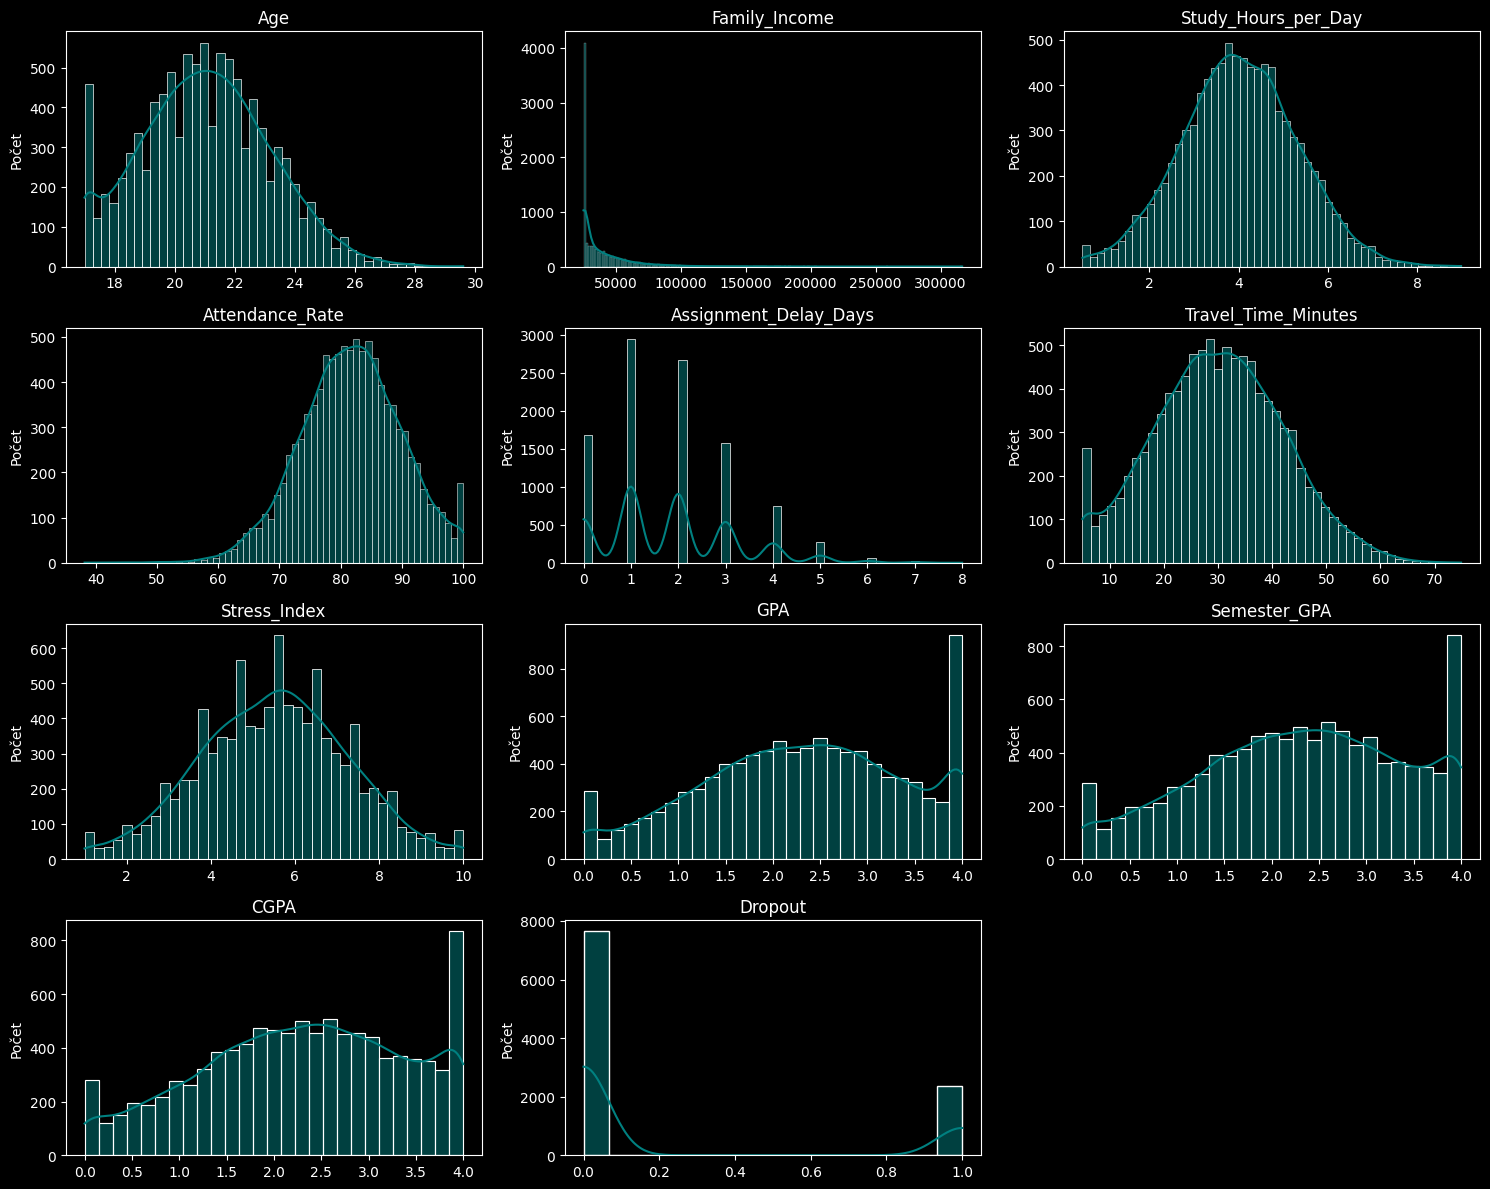

In [20]:
plt.style.use('dark_background')
sns.set_palette("viridis")

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Student_ID', errors='ignore')

fig, axes = plt.subplots(int(np.ceil(len(numeric_cols) / 3)), 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(col, color='white')
    axes[i].set_ylabel('Počet', color='white')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

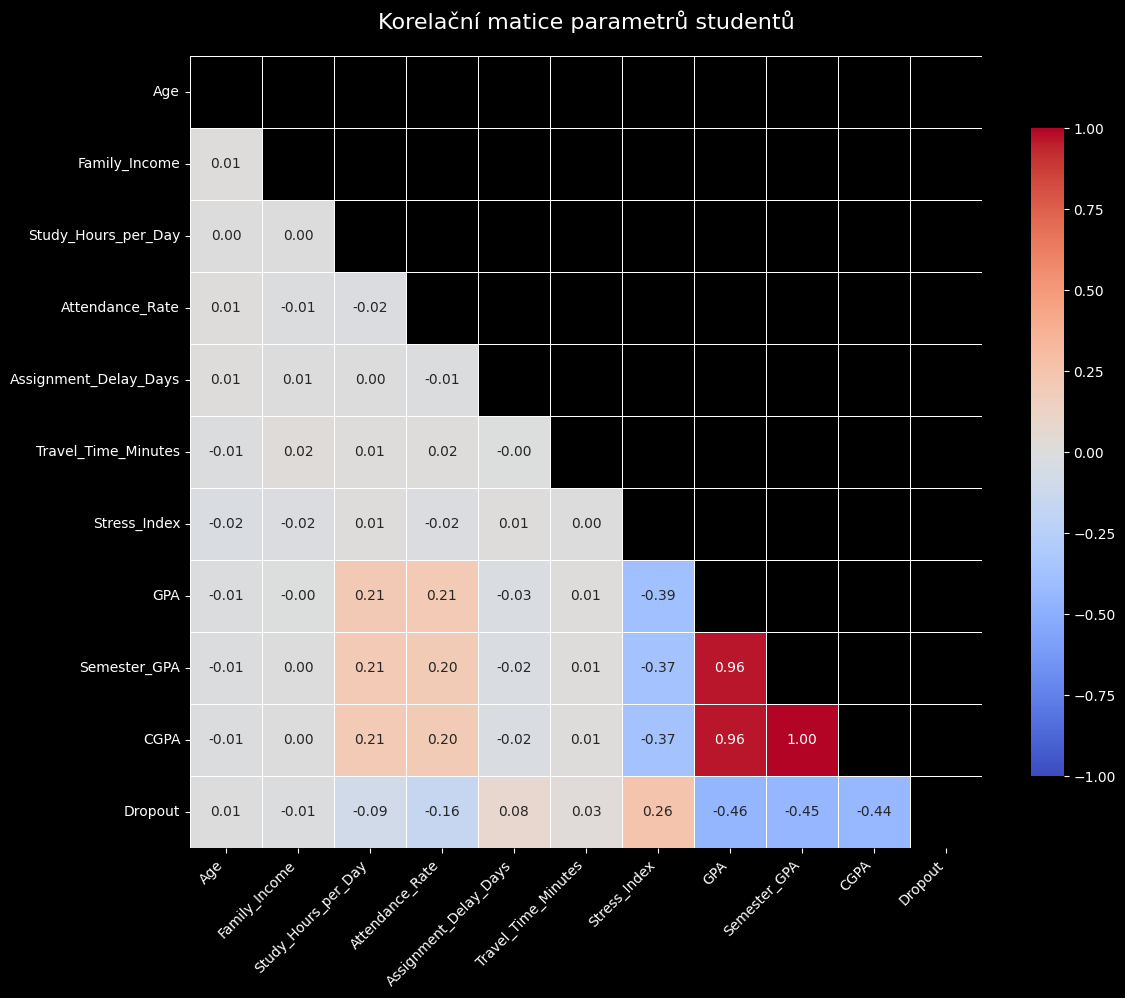

In [21]:
plt.figure(figsize=(12, 10))

corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Korelační matice parametrů studentů', fontsize=16, pad=20, color='white')
plt.xticks(color='white', rotation=45, ha='right')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

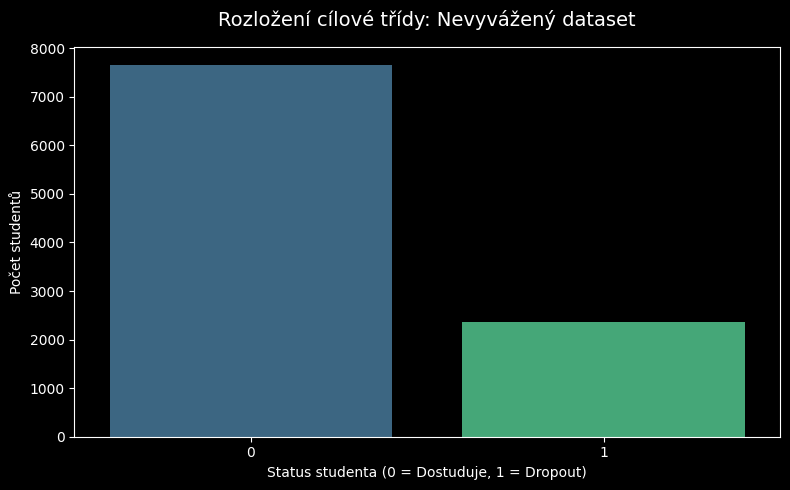

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Dropout', hue='Dropout', palette='viridis', legend=False)

plt.title('Rozložení cílové třídy: Nevyvážený dataset', fontsize=14, pad=15, color='white')
plt.ylabel('Počet studentů', color='white')
plt.xlabel('Status studenta (0 = Dostuduje, 1 = Dropout)', color='white')
plt.xticks(color='white')
plt.yticks(color='white')

plt.tight_layout()
plt.show()